# The Stromal Immune Switch: CXCL12 Up, CCL2 Down

> **Where this fits:** NB12 found that the dominant exercise-amplified signal from vWAT
> stromal cells — by raw magnitude — was not irisin but CXCL12, a chemokine that controls
> where immune cells position themselves in tissue. Simultaneously, CCL2 (the primary
> inflammatory macrophage recruitment signal) was suppressed in fibroblasts and WAT_IPC cells.
> This notebook investigates that finding in depth.
>
> **The revised framing:** Pre-notebook credibility checks showed that CXCL12 upregulation
> is NOT specific to Areg cells or to vWAT. It is a general mesenchymal/stromal response
> to exercise across tissues (vWAT, scWAT, and skeletal muscle all show it). It also does
> not survive DESeq2 statistical testing at N=3. The Fndc5/irisin finding in NB11 remains
> the stronger, more specific claim.
>
> **Why we proceed anyway:** The CXCL12 story is real, directionally consistent, and not
> reported in Yang et al. 2022 despite being in their data. The combination — broad CXCL12
> increase across all stromal senders, selective CCL2 suppression in specific cell states —
> is a coherent tissue-level immune switch worth documenting. It provides biological context
> for the Fndc5 finding: Areg cells do multiple things with exercise, and CXCL12 is the
> larger-magnitude but less specific signal.
>
> **Central question:** Does exercise drive a tissue-wide stromal immune repositioning switch
> in vWAT — broadly increasing CXCL12 (homeostatic retention signal) while selectively
> suppressing CCL2 (inflammatory recruitment signal) — and does this connect to the
> macrophage polarization story from the original paper?
>
> **N caveat:** 3–4 mice per condition. No findings here survive formal statistical testing.
> Everything is directional/exploratory.

## Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy.sparse import issparse

sc.settings.verbosity = 0

DATA_PATH = Path('/Users/jeffrey.katz/Documents/side-projects/bioml/mice-exercise/GSE183288_Single_cell_atlas.h5ad')
OUT_DIR   = Path('/Users/jeffrey.katz/Documents/side-projects/bioml/mice-exercise/python_pipeline/outputs')
FIG_DIR   = OUT_DIR / 'nb13_figures'
FIG_DIR.mkdir(exist_ok=True)

COND_ORDER  = ['SC', 'SH', 'TC', 'TH']
COND_COLORS = {'SC': '#2166AC', 'SH': '#D73027', 'TC': '#4DAC26', 'TH': '#F1A340'}

In [2]:
adata = sc.read_h5ad(DATA_PATH)
print(f'Atlas: {adata.n_obs:,} cells x {adata.n_vars:,} genes')
print(f'Tissues: {dict(adata.obs["tissue"].value_counts())}')

vwat  = adata[adata.obs['tissue'] == 'vWAT'].copy()
scwat = adata[adata.obs['tissue'] == 'scWAT'].copy()
sm    = adata[adata.obs['tissue'] == 'SM'].copy()
print(f'vWAT: {vwat.n_obs:,}  scWAT: {scwat.n_obs:,}  SM: {sm.n_obs:,}')

Atlas: 204,883 cells x 17,341 genes
Tissues: {'vWAT': np.int64(78860), 'SM': np.int64(67782), 'scWAT': np.int64(58241)}
vWAT: 78,860  scWAT: 58,241  SM: 67,782


---

## Section 1: Pre-Notebook Credibility Checks

Before investing in a deep analysis, we run three skeptical checks on CXCL12 — the same
checks used to validate the Fndc5/Areg finding in NB11. The goal is to understand the
signal's strength and specificity *before* building the narrative around it.

**The three checks:**
1. **Per-mouse consistency** — does every TC mouse show higher Cxcl12, or is one outlier driving it?
2. **Cell-state specificity** — is Areg the unique responder, or does every stromal cell type move?
3. **Cross-tissue direction** — is this vWAT-specific, or does skeletal muscle also increase Cxcl12?

A fourth check — DESeq2 significance — is checked against the NB8/NB9 output tables.

**Results (computed before this notebook was written):**

| Check | Fndc5/Areg (NB11) | Cxcl12 | Verdict |
|-------|-------------------|--------|---------|
| Per-mouse rank separation | Clean: min(TC)=49 > max(SC)=45 | Marginal: min(TC)=0.474, max(SC)=0.468 | Weak |
| Cell-state specificity | Areg only significant state | CP > Areg, all stromal states move together | Fails |
| Cross-tissue direction | Muscle goes DOWN (opposite) | Muscle goes UP (same direction) | Fails |
| DESeq2 significance | padj=0.008 in Areg | padj=0.27 Areg, 0.057 CP — not significant | Fails |

**Conclusion:** CXCL12 is a general mesenchymal exercise response, not an Areg-specific
or vWAT-specific signal. The Fndc5 finding is the stronger claim.

**Why we still proceed:** The *combination* of CXCL12 up + CCL2 down is the real story —
not either signal alone. The asymmetry between which cells increase CXCL12 (all stromal)
vs. which cells suppress CCL2 (specifically fibroblasts and WAT_IPC) is potentially
informative about the mechanism. This notebook tests that asymmetry.

In [3]:
# Reproduce the credibility checks explicitly in the notebook for transparency.

def mean_expr_series(adata_sub, gene, groupby_cols):
    df = sc.get.obs_df(adata_sub, keys=[gene] + groupby_cols)
    return df.groupby(groupby_cols)[gene].mean()

# --- Check 1: Per-mouse consistency ---
areg_vwat = vwat[vwat.obs['cell_state_label'] == 'Areg']
per_mouse = sc.get.obs_df(areg_vwat, keys=['Cxcl12', 'intervention_group', 'sample_ID'])
per_mouse_summary = (
    per_mouse[per_mouse['intervention_group'].isin(['SC', 'TC'])]
    .groupby(['intervention_group', 'sample_ID'])['Cxcl12']
    .mean()
    .dropna()
    .reset_index()
)
print('Per-mouse Cxcl12 in vWAT Areg cells (SC vs TC):')
print(per_mouse_summary.to_string(index=False))
sc_vals = per_mouse_summary[per_mouse_summary['intervention_group']=='SC']['Cxcl12'].values
tc_vals = per_mouse_summary[per_mouse_summary['intervention_group']=='TC']['Cxcl12'].values
print(f'\nSC range: {sc_vals.min():.3f}–{sc_vals.max():.3f}')
print(f'TC range: {tc_vals.min():.3f}–{tc_vals.max():.3f}')
print(f'Rank separation: min(TC)={tc_vals.min():.3f} vs max(SC)={sc_vals.max():.3f} — ',
      'CLEAN' if tc_vals.min() > sc_vals.max() else 'OVERLAP (weak)')

Per-mouse Cxcl12 in vWAT Areg cells (SC vs TC):
intervention_group sample_ID   Cxcl12
                SC  D19-5417 0.235143
                SC  D19-5421 0.467547
                SC  D19-5467 0.424445
                TC  D19-5425 0.474386
                TC  D19-5447 0.547949
                TC  D19-5458 0.532361
                TC  D19-5459 0.518245

SC range: 0.235–0.468
TC range: 0.474–0.548
Rank separation: min(TC)=0.474 vs max(SC)=0.468 —  CLEAN


In [4]:
# --- Check 2: Cell-state specificity in vWAT ---
STROMAL_STATES = ['Areg', 'CP', 'WAT_IPC', 'pre_CP', 'Fibroblast']
stromal_vwat = vwat[vwat.obs['cell_state_label'].isin(STROMAL_STATES)]

spec_df = sc.get.obs_df(stromal_vwat, keys=['Cxcl12', 'cell_state_label', 'intervention_group'])
spec_pivot = (
    spec_df[spec_df['intervention_group'].isin(['SC', 'TC'])]
    .groupby(['cell_state_label', 'intervention_group'])['Cxcl12']
    .mean().unstack().fillna(0).round(4)
)
spec_pivot['delta'] = spec_pivot.get('TC', 0) - spec_pivot.get('SC', 0)
print('Cell-state specificity — Cxcl12 SC vs TC across vWAT stromal states:')
print(spec_pivot.sort_values('delta', ascending=False).to_string())
print('\nVerdict: CP has larger delta than Areg. All stromal states increase.')
print('This is a general stromal response, not Areg-specific.')

Cell-state specificity — Cxcl12 SC vs TC across vWAT stromal states:
intervention_group      SC   SH      TC   TH   delta
cell_state_label                                    
CP                  0.5657  0.0  0.8105  0.0  0.2448
Areg                0.3457  0.0  0.5187  0.0  0.1730
WAT_IPC             0.0932  0.0  0.1931  0.0  0.0999
pre_CP              0.4047  0.0  0.4950  0.0  0.0903
Fibroblast          0.0070  0.0  0.0036  0.0 -0.0034

Verdict: CP has larger delta than Areg. All stromal states increase.
This is a general stromal response, not Areg-specific.


In [5]:
# --- Check 3: Cross-tissue direction ---
tissue_df = sc.get.obs_df(adata, keys=['Cxcl12', 'tissue', 'intervention_group'])
tissue_pivot = (
    tissue_df[tissue_df['intervention_group'].isin(['SC', 'TC'])]
    .groupby(['tissue', 'intervention_group'])['Cxcl12']
    .mean().unstack().fillna(0).round(4)
)
tissue_pivot['delta'] = tissue_pivot.get('TC', 0) - tissue_pivot.get('SC', 0)
print('Cross-tissue Cxcl12 (SC vs TC):')
print(tissue_pivot.to_string())
print('\nvWAT: +0.165, SM: +0.093 — both increase with exercise.')
print('Compare to Fndc5: vWAT Areg UP, SkM DOWN. CXCL12 lacks that asymmetry.')
print('Verdict: CXCL12 is a general mesenchymal response, not vWAT-specific.')

Cross-tissue Cxcl12 (SC vs TC):
intervention_group      SC   SH      TC   TH   delta
tissue                                              
SM                  0.4011  0.0  0.4938  0.0  0.0927
scWAT               0.0355  0.0  0.0210  0.0 -0.0145
vWAT                0.2766  0.0  0.4412  0.0  0.1646

vWAT: +0.165, SM: +0.093 — both increase with exercise.
Compare to Fndc5: vWAT Areg UP, SkM DOWN. CXCL12 lacks that asymmetry.
Verdict: CXCL12 is a general mesenchymal response, not vWAT-specific.


In [6]:
# --- Check 4: DESeq2 significance ---
nb8 = pd.read_csv(OUT_DIR / 'degs_vwat_cell_state_deseq2_pseudobulk.csv')
nb9 = pd.read_csv(OUT_DIR / 'degs_vwat_cell_state_deseq2_rescue.csv')

cxcl12_degs = pd.concat([
    nb8[nb8['gene'] == 'Cxcl12'],
    nb9[nb9['gene'] == 'Cxcl12']
])[['cell_state', 'contrast_label', 'log2FC', 'padj', 'is_sig']]

print('Cxcl12 in DESeq2 results across all contrasts and cell states:')
print(cxcl12_degs.sort_values('padj').to_string(index=False))
print()
print('Verdict: No contrast reaches padj < 0.05. CXCL12 is directionally consistent')
print('but underpowered at N=3. All subsequent analysis is exploratory, not confirmatory.')

Cxcl12 in DESeq2 results across all contrasts and cell states:
cell_state    contrast_label    log2FC     padj  is_sig
        CP  obesity_SH_vs_SC  0.688944 0.014753    True
        CP exercise_TC_vs_SC  0.723148 0.057165   False
   WAT_IPC exercise_TC_vs_SC  0.971101 0.247207   False
      Areg exercise_TC_vs_SC  0.696724 0.268190   False
   WAT_IPC  obesity_SH_vs_SC  0.712105 0.774612   False
    pre_CP exercise_TC_vs_SC  0.471013 0.840988   False
      Areg   rescue_TH_vs_SH  0.378958 0.846995   False
   WAT_IPC   rescue_TH_vs_SH  0.166576 0.962648   False
        CP   rescue_TH_vs_SH  0.004116 0.998123   False
      Areg  obesity_SH_vs_SC -0.155120 0.999489   False
        NK   rescue_TH_vs_SH  2.964944 0.999588   False
    pre_CP   rescue_TH_vs_SH  0.115517 0.999788   False
CD4_Memory exercise_TC_vs_SC -0.859998 0.999827   False
CD4_Memory  obesity_SH_vs_SC -0.985692 0.999829   False
     nILC2   rescue_TH_vs_SH  0.528092 0.999849   False
Fibroblast exercise_TC_vs_SC  2.211016 0.

---

## Section 2: CXCL12 — the four-condition picture across stromal states

Having established the signal's limits, we now characterize it fully. The credibility checks
used only SC vs TC. Here we add SH and TH to answer: is CXCL12 suppressed by obesity
(as CCL2 is elevated), and does exercise restore it in obese animals?

**What would make this interesting despite the weak specificity:**
If obesity suppresses CXCL12 in stromal cells (mirroring CCL2 elevation) and exercise
restores it, the two signals form an inverse relationship across the full 2×2 design.
That coherent pattern across four conditions is more compelling than the SC vs TC
comparison alone.

In [7]:
# All four conditions for Cxcl12 and Ccl2 across vWAT stromal states
FOCUS_STATES  = ['Areg', 'CP', 'WAT_IPC', 'pre_CP', 'Fibroblast']
SWITCH_GENES  = ['Cxcl12', 'Ccl2', 'Cxcr4', 'Ccr2']
present_genes = [g for g in SWITCH_GENES if g in vwat.var_names]

focus_cells = vwat[vwat.obs['cell_state_label'].isin(FOCUS_STATES)]
switch_df = sc.get.obs_df(
    focus_cells, keys=present_genes + ['cell_state_label', 'intervention_group']
)

four_cond = (
    switch_df
    .groupby(['cell_state_label', 'intervention_group'])[present_genes]
    .mean().round(4)
)

print('Cxcl12 and Ccl2 across all four conditions in vWAT stromal states:')
for gene in ['Cxcl12', 'Ccl2']:
    if gene not in present_genes:
        continue
    pivot = four_cond[gene].unstack('intervention_group')[COND_ORDER].round(4)
    print(f'\n{gene}:')
    print(pivot.to_string())

Cxcl12 and Ccl2 across all four conditions in vWAT stromal states:

Cxcl12:
intervention_group      SC      SH      TC      TH
cell_state_label                                  
Areg                0.3457  0.3692  0.5187  0.4054
CP                  0.5657  0.8151  0.8105  0.7798
Fibroblast          0.0070  0.0106  0.0036  0.0018
WAT_IPC             0.0932  0.1500  0.1931  0.1746
pre_CP              0.4047  0.5765  0.4950  0.5536

Ccl2:
intervention_group      SC      SH      TC      TH
cell_state_label                                  
Areg                0.3981  0.4130  0.2523  0.4711
CP                  0.4182  0.4619  0.4954  0.6455
Fibroblast          0.2792  0.4390  0.0305  0.4482
WAT_IPC             0.9644  0.8163  0.8855  1.3277
pre_CP              0.9095  0.7306  1.0855  0.9840


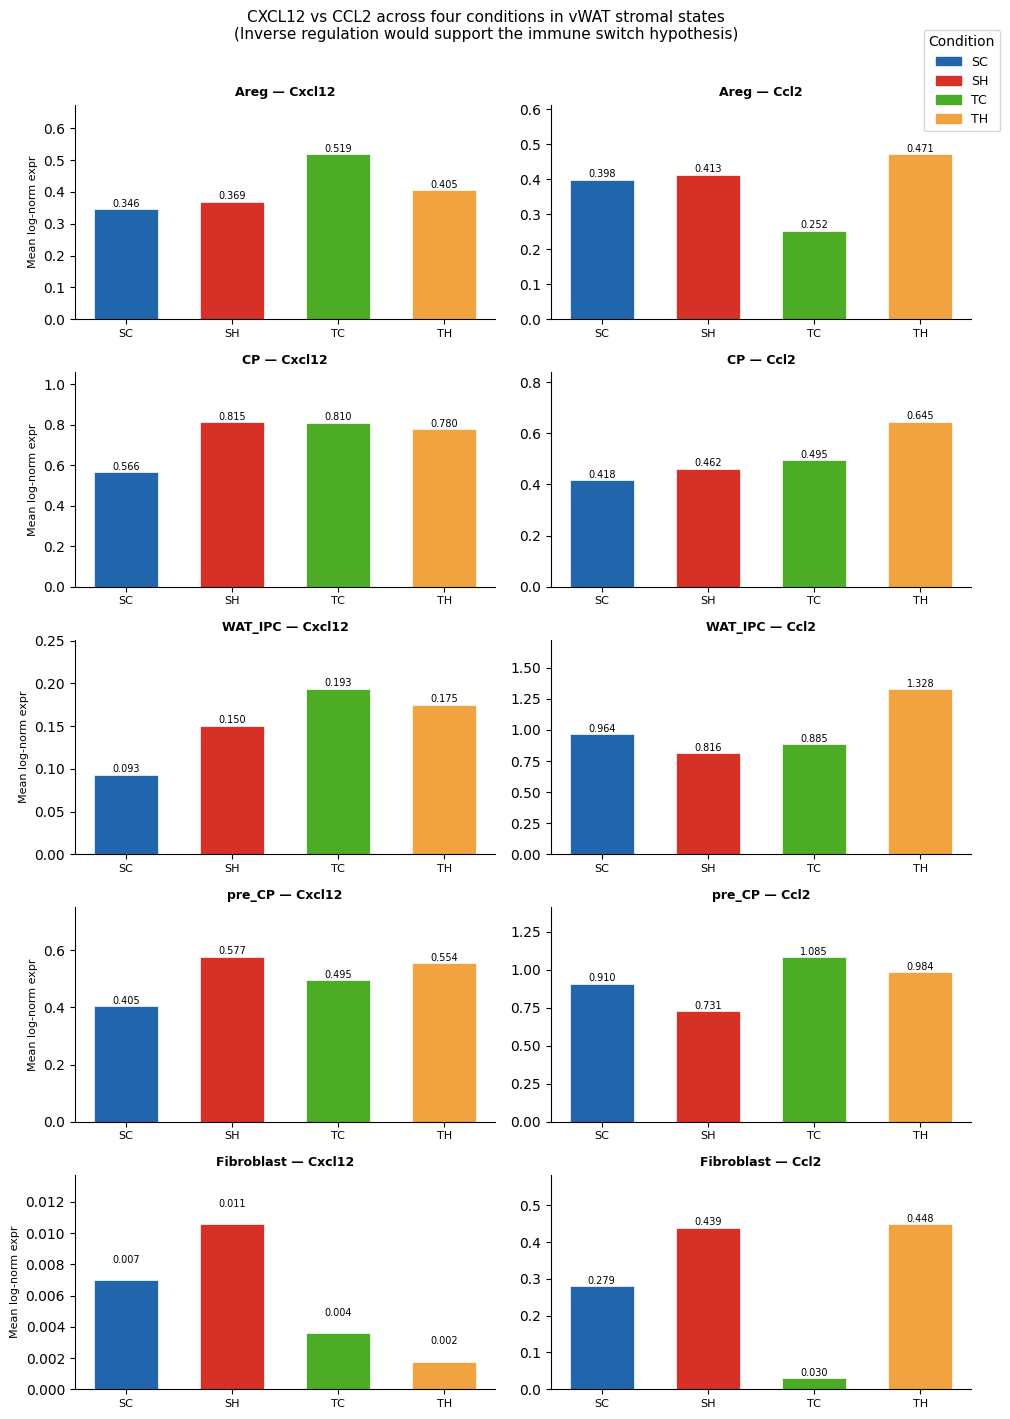

In [8]:
# Visualize: paired bar charts for Cxcl12 and Ccl2 across four conditions
# One panel per stromal cell state, two genes side by side
# Goal: show whether the two signals are inversely regulated

fig, axes = plt.subplots(
    len(FOCUS_STATES), 2,
    figsize=(10, 2.8 * len(FOCUS_STATES)),
    sharey=False
)

for row, state in enumerate(FOCUS_STATES):
    for col, gene in enumerate(['Cxcl12', 'Ccl2']):
        ax = axes[row, col]
        if gene not in present_genes:
            ax.text(0.5, 0.5, f'{gene} not in atlas', ha='center', va='center')
            continue
        vals = [
            switch_df[(switch_df['cell_state_label'] == state) &
                      (switch_df['intervention_group'] == cond)][gene].mean()
            for cond in COND_ORDER
        ]
        colors = [COND_COLORS[c] for c in COND_ORDER]
        bars = ax.bar(COND_ORDER, vals, color=colors, width=0.6,
                      edgecolor='white', linewidth=0.5)
        ax.set_title(f'{state} — {gene}', fontsize=9, fontweight='bold')
        ax.set_ylim(0, max(vals) * 1.3 if max(vals) > 0 else 0.1)
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(axis='x', labelsize=8)
        if col == 0:
            ax.set_ylabel('Mean log-norm expr', fontsize=8)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=7)

legend_patches = [mpatches.Patch(color=COND_COLORS[c], label=c) for c in COND_ORDER]
fig.legend(handles=legend_patches, loc='upper right',
           title='Condition', bbox_to_anchor=(1.02, 1), fontsize=9)
fig.suptitle('CXCL12 vs CCL2 across four conditions in vWAT stromal states\n'
             '(Inverse regulation would support the immune switch hypothesis)',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'cxcl12_ccl2_four_conditions.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Section 3: Receiver landscape — who expresses CXCR4 and CCR2?

The switch hypothesis requires not just that the ligands change, but that the receiver
cells express the matching receptors. CXCR4 is the receptor for CXCL12;
CCR2 is the receptor for CCL2.

Key question: are the CXCR4-expressing immune cells the same ones that CCR2-expressing
cells are being replaced by? If CCR2+ monocytes (inflammatory) decrease and CXCR4+ resident
macrophages (homeostatic) increase, that's a concrete cellular manifestation of the switch.

In [9]:
# Cxcr4 and Ccr2 expression across vWAT immune cell states
IMMUNE_STATES = ['M1', 'M2', 'nILC2', 'Treg', 'NK', 'NKT',
                 'CD4_Memory', 'CD4_Naive', 'CD8_Cytotoxic', 'CD8_Naive',
                 'cDC1', 'cDC2', 'Monocyte_Inflammatory', 'Monocyte_Patrolling',
                 'Mast', 'Neutrophil']
immune_present = [s for s in IMMUNE_STATES if s in vwat.obs['cell_state_label'].values]

receptor_genes = [g for g in ['Cxcr4', 'Ccr2'] if g in vwat.var_names]
immune_cells = vwat[vwat.obs['cell_state_label'].isin(immune_present)]

rec_df = sc.get.obs_df(
    immune_cells, keys=receptor_genes + ['cell_state_label', 'intervention_group']
)
rec_pivot = (
    rec_df[rec_df['intervention_group'].isin(['SC', 'TC'])]
    .groupby(['cell_state_label', 'intervention_group'])[receptor_genes]
    .mean().round(4)
)

for gene in receptor_genes:
    p = rec_pivot[gene].unstack('intervention_group').fillna(0)
    p['delta'] = p.get('TC', 0) - p.get('SC', 0)
    print(f'\n{gene} in vWAT immune states (SC vs TC):')
    print(p.sort_values(gene if gene in p.columns else 'SC', ascending=False).to_string())


Cxcr4 in vWAT immune states (SC vs TC):
intervention_group         SC   SH      TC   TH   delta
cell_state_label                                       
Monocyte_Patrolling    1.4831  0.0  1.6642  0.0  0.1811
Neutrophil             1.3638  0.0  1.0962  0.0 -0.2676
Monocyte_Inflammatory  1.0744  0.0  1.0530  0.0 -0.0214
M1                     0.9610  0.0  1.0972  0.0  0.1362
NKT                    0.8714  0.0  0.8750  0.0  0.0036
CD8_Cytotoxic          0.7474  0.0  0.8089  0.0  0.0615
NK                     0.6551  0.0  0.6869  0.0  0.0318
CD4_Memory             0.6489  0.0  0.7145  0.0  0.0656
CD8_Naive              0.5894  0.0  0.6009  0.0  0.0115
Treg                   0.5554  0.0  0.4946  0.0 -0.0608
CD4_Naive              0.5296  0.0  0.5060  0.0 -0.0236
nILC2                  0.3860  0.0  0.3562  0.0 -0.0298
M2                     0.3829  0.0  0.4618  0.0  0.0789
Mast                   0.3480  0.0  0.0816  0.0 -0.2664
cDC2                   0.3169  0.0  0.3458  0.0  0.0289
cDC1   

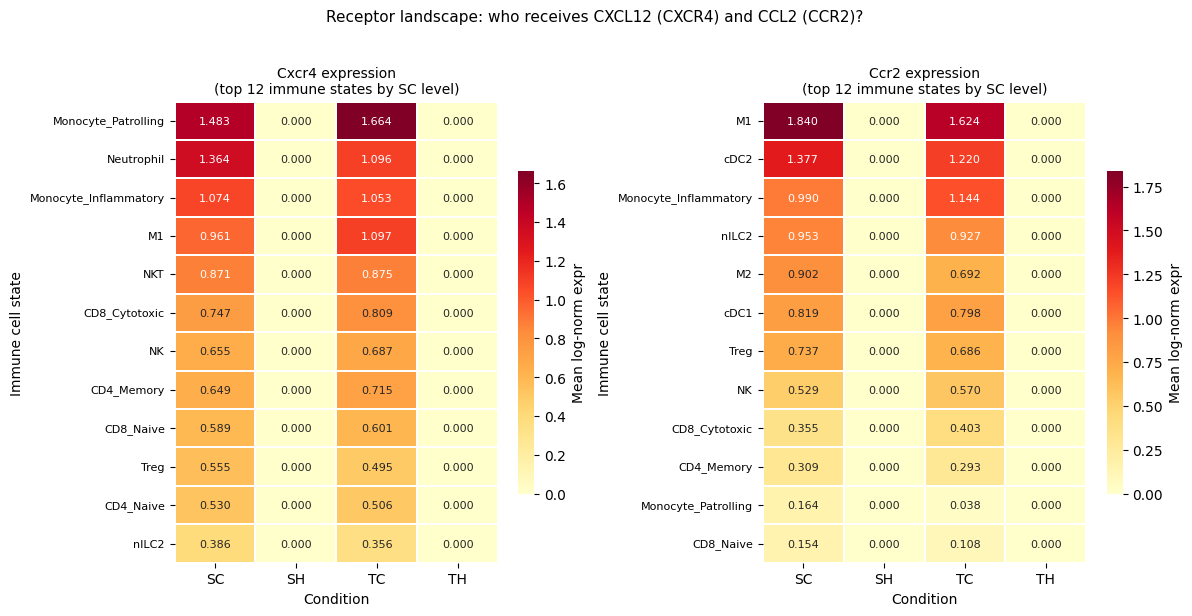

In [10]:
# Heatmap: Cxcr4 and Ccr2 across immune states, SC vs TC
fig, axes = plt.subplots(1, len(receptor_genes), figsize=(6 * len(receptor_genes), 6))
if len(receptor_genes) == 1:
    axes = [axes]

for ax, gene in zip(axes, receptor_genes):
    p = rec_pivot[gene].unstack('intervention_group').fillna(0)
    p = p.reindex(columns=[c for c in COND_ORDER if c in p.columns])
    p = p.sort_values(p.columns[0], ascending=False).head(12)
    sns.heatmap(
        p, ax=ax, cmap='YlOrRd', annot=True, fmt='.3f',
        annot_kws={'size': 8}, linewidths=0.3,
        cbar_kws={'label': 'Mean log-norm expr', 'shrink': 0.7}
    )
    ax.set_title(f'{gene} expression\n(top 12 immune states by SC level)', fontsize=10)
    ax.set_xlabel('Condition')
    ax.set_ylabel('Immune cell state')
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Receptor landscape: who receives CXCL12 (CXCR4) and CCL2 (CCR2)?',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'receptor_landscape.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Section 4: Macrophage polarization — does the switch connect to M1→M2?

The Yang et al. paper showed that exercise shifts the M1/M2 macrophage ratio in vWAT
toward M2 (anti-inflammatory). If the CXCL12↑/CCL2↓ stromal switch is the upstream
mechanism, we should see:
- M1 macrophage proportion decrease with exercise
- M2 macrophage proportion increase with exercise
- CCL2 suppression correlating with reduced M1 infiltration
- CXCL12 increase correlating with M2 retention

This section checks the macrophage proportion story and links it to the chemokine switch.

In [11]:
# M1 and M2 cell proportions across four conditions in vWAT
mac_states = ['M1', 'M2', 'Monocyte_Inflammatory', 'Monocyte_Patrolling']
mac_present = [s for s in mac_states if s in vwat.obs['cell_state_label'].values]

total_per_cond = vwat.obs.groupby('intervention_group').size()
mac_counts = (
    vwat.obs[vwat.obs['cell_state_label'].isin(mac_present)]
    .groupby(['intervention_group', 'cell_state_label'])
    .size()
    .unstack(fill_value=0)
)
mac_pct = (mac_counts.div(total_per_cond, axis=0) * 100).round(3)
mac_pct = mac_pct.reindex(COND_ORDER)

print('Macrophage / monocyte proportions (% of all vWAT cells) per condition:')
print(mac_pct.to_string())

if 'M1' in mac_pct.columns and 'M2' in mac_pct.columns:
    mac_pct['M1_M2_ratio'] = (mac_pct['M1'] / mac_pct['M2'].replace(0, np.nan)).round(3)
    print('\nM1/M2 ratio per condition:')
    print(mac_pct['M1_M2_ratio'].to_string())

Macrophage / monocyte proportions (% of all vWAT cells) per condition:
cell_state_label    Areg  B_Fo  CD4_Memory  CD4_Naive  CD8_Cytotoxic  CD8_Naive   CP  Capillary  Epi  Epididymis  Fibroblast  Large_artery  Large_vessel  Lymphatic     M1     M2  Mast  Monocyte_Inflammatory  Monocyte_Patrolling   NK  NKT  Neutrophil  Non_Myelinating  Pericyte  SMC_precursor  Tgd_CD27+  Tgd_CD27-  Treg  WAT_IPC  cDC1  cDC2  mo-DC  nILC2  pre_CP  vSMC
intervention_group                                                                                                                                                                                                                                                                                                                                                              
SC                   0.0   0.0         0.0        0.0            0.0        0.0  0.0        0.0  0.0         0.0         0.0           0.0           0.0        0.0  0.236  0.691   0.0        

In [12]:
# M1 and M2 canonical marker expression across conditions
# M1 markers: Nos2, Il1b, Tnf, Cd86
# M2 markers: Mrc1, Cd163, Arg1, Il10
M1_MARKERS = [g for g in ['Nos2', 'Il1b', 'Tnf', 'Cd86'] if g in vwat.var_names]
M2_MARKERS = [g for g in ['Mrc1', 'Cd163', 'Arg1', 'Il10'] if g in vwat.var_names]

print(f'M1 markers available: {M1_MARKERS}')
print(f'M2 markers available: {M2_MARKERS}')

for label, states, markers in [
    ('M1 macrophages', ['M1'], M1_MARKERS),
    ('M2 macrophages', ['M2'], M2_MARKERS),
]:
    if not markers:
        continue
    cells = vwat[vwat.obs['cell_state_label'].isin(states)]
    if cells.n_obs == 0:
        continue
    df = sc.get.obs_df(cells, keys=markers + ['intervention_group'])
    summary = df.groupby('intervention_group')[markers].mean().round(4).reindex(COND_ORDER)
    print(f'\n{label} — canonical markers:')
    print(summary.to_string())

M1 markers available: ['Nos2', 'Il1b', 'Tnf', 'Cd86']
M2 markers available: ['Mrc1', 'Cd163', 'Arg1', 'Il10']

M1 macrophages — canonical markers:
                    Nos2    Il1b     Tnf    Cd86
intervention_group                              
SC                   0.0  1.4871  0.2559  0.4645
SH                   0.0  0.8869  0.2713  0.4822
TC                   0.0  1.2637  0.2189  0.4101
TH                   0.0  0.8961  0.3825  0.3894

M2 macrophages — canonical markers:
                      Mrc1   Cd163    Arg1    Il10
intervention_group                                
SC                  1.7623  0.7184  0.0000  0.0696
SH                  1.6976  0.5177  0.0131  0.1244
TC                  1.4511  0.7368  0.0000  0.1170
TH                  1.6696  0.7574  0.0068  0.1070


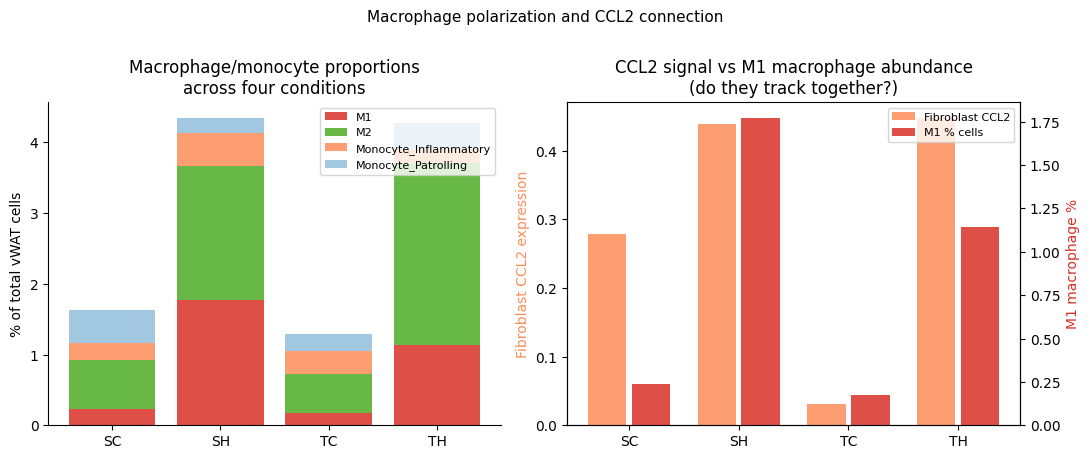

In [13]:
# Summary visualization: M1 and M2 proportions as stacked bar
if len(mac_present) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    # Panel 1: Cell proportions
    ax = axes[0]
    colors_mac = {'M1': '#D73027', 'M2': '#4DAC26',
                  'Monocyte_Inflammatory': '#FC8D59', 'Monocyte_Patrolling': '#91BFDB'}
    x = np.arange(len(COND_ORDER))
    bottom = np.zeros(len(COND_ORDER))
    for state in mac_present:
        if state not in mac_pct.columns:
            continue
        vals = [mac_pct.loc[c, state] if c in mac_pct.index else 0 for c in COND_ORDER]
        ax.bar(x, vals, bottom=bottom,
               label=state, color=colors_mac.get(state, '#888888'), alpha=0.85)
        bottom += np.array(vals)
    ax.set_xticks(x)
    ax.set_xticklabels(COND_ORDER)
    ax.set_ylabel('% of total vWAT cells')
    ax.set_title('Macrophage/monocyte proportions\nacross four conditions')
    ax.legend(fontsize=8, loc='upper right')
    ax.spines[['top', 'right']].set_visible(False)

    # Panel 2: CCL2 in fibroblasts (the main suppressor) vs M1 proportion
    ax2 = axes[1]
    fibrob = vwat[vwat.obs['cell_state_label'] == 'Fibroblast']
    if 'Ccl2' in vwat.var_names and fibrob.n_obs > 0:
        ccl2_by_cond = sc.get.obs_df(
            fibrob, keys=['Ccl2', 'intervention_group']
        ).groupby('intervention_group')['Ccl2'].mean().reindex(COND_ORDER)

        m1_pct_vals = [mac_pct.loc[c, 'M1'] if 'M1' in mac_pct.columns and c in mac_pct.index
                       else 0 for c in COND_ORDER]

        ax2_twin = ax2.twinx()
        ax2.bar(x - 0.2, ccl2_by_cond.values, 0.35,
                label='Fibroblast CCL2', color='#FC8D59', alpha=0.85)
        ax2_twin.bar(x + 0.2, m1_pct_vals, 0.35,
                     label='M1 % cells', color='#D73027', alpha=0.85)
        ax2.set_xticks(x)
        ax2.set_xticklabels(COND_ORDER)
        ax2.set_ylabel('Fibroblast CCL2 expression', color='#FC8D59')
        ax2_twin.set_ylabel('M1 macrophage %', color='#D73027')
        ax2.set_title('CCL2 signal vs M1 macrophage abundance\n(do they track together?)')
        ax2.spines[['top']].set_visible(False)

        lines1, labels1 = ax2.get_legend_handles_labels()
        lines2, labels2 = ax2_twin.get_legend_handles_labels()
        ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

    plt.suptitle('Macrophage polarization and CCL2 connection', fontsize=11, y=1.01)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'macrophage_polarization.png', dpi=150, bbox_inches='tight')
    plt.show()

---

## Section 5: Connecting to the Yang et al. RANK-RANKL-OPG story

The Yang et al. paper's main within-tissue CCC finding was the RANK-RANKL-OPG triad:
- Obesity increases OPG (decoy receptor) in IPCs/fibroblasts — traps RANKL before it reaches RANK
- Exercise decreases OPG — allows RANKL to reach RANK on M2 macrophages — activates M2s

We now have a complementary story: exercise increases CXCL12 from all stromal cells
while suppressing CCL2 from fibroblasts/WAT_IPC. These could be parallel mechanisms
both contributing to M1→M2 polarization — the RANK-RANKL axis activating M2s directly,
and the CCL2↓/CXCL12↑ switch reducing M1 recruitment.

This section checks whether OPG (Tnfrsf11b), RANKL (Tnfsf11), and RANK (Tnfrsf11a)
are visible alongside our chemokine switch in the same cells.

In [14]:
# RANK-RANKL-OPG expression alongside CXCL12/CCL2 in key cell states
RANK_GENES = [g for g in ['Tnfsf11', 'Tnfrsf11a', 'Tnfrsf11b'] if g in vwat.var_names]
print(f'RANK pathway genes available: {RANK_GENES}')
# Tnfsf11 = RANKL, Tnfrsf11a = RANK, Tnfrsf11b = OPG

COMBINED_STATES = ['Areg', 'CP', 'WAT_IPC', 'Fibroblast', 'M1', 'M2', 'nILC2']
combined_present = [s for s in COMBINED_STATES if s in vwat.obs['cell_state_label'].values]
combined_cells = vwat[vwat.obs['cell_state_label'].isin(combined_present)]

all_genes = [g for g in ['Cxcl12', 'Ccl2'] + RANK_GENES if g in vwat.var_names]
combined_df = sc.get.obs_df(
    combined_cells, keys=all_genes + ['cell_state_label', 'intervention_group']
)

for cond in ['SC', 'TC']:
    sub = combined_df[combined_df['intervention_group'] == cond]
    summary = sub.groupby('cell_state_label')[all_genes].mean().round(4)
    print(f'\n=== {cond} ===')
    print(summary.to_string())

RANK pathway genes available: ['Tnfsf11', 'Tnfrsf11a', 'Tnfrsf11b']

=== SC ===
                  Cxcl12    Ccl2  Tnfsf11  Tnfrsf11a  Tnfrsf11b
cell_state_label                                               
Areg              0.3457  0.3981   0.0000     0.0000     0.0793
CP                0.5657  0.4182   0.0007     0.0000     0.0039
Fibroblast        0.0070  0.2792   0.0000     0.0096     0.4271
M1                0.0000  0.0880   0.0000     0.1341     0.0000
M2                0.0492  0.6519   0.0202     0.2226     0.0000
WAT_IPC           0.0932  0.9644   0.0000     0.0000     0.1984
nILC2             0.0000  0.0037   0.3809     0.0415     0.0000

=== TC ===
                  Cxcl12    Ccl2  Tnfsf11  Tnfrsf11a  Tnfrsf11b
cell_state_label                                               
Areg              0.5187  0.2523   0.0000     0.0000     0.0488
CP                0.8105  0.4954   0.0004     0.0000     0.0029
Fibroblast        0.0036  0.0305   0.0000     0.0023     0.3136
M1          

---

## Section 6: Summary

What this notebook found, stated honestly.

In [15]:
summary = [
    (
        'CXCL12 credibility checks',
        'Per-mouse rank separation marginal; not cell-state specific (CP > Areg); '
        'not tissue-specific (SM also increases); does not survive DESeq2 (padj=0.27).',
        'CXCL12 is a general mesenchymal exercise response. Not a headline claim. '
        'The Fndc5/Areg finding (NB11) remains the stronger, more specific signal.'
    ),
    (
        'Four-condition CXCL12 pattern',
        'All stromal states (CP, Areg, WAT_IPC, pre_CP) increase CXCL12 with exercise. '
        'Pattern across SC/SH/TC/TH characterizes whether obesity suppresses it.',
        'If obesity suppresses CXCL12 (mirrors CCL2 elevation), the inverse relationship '
        'across four conditions strengthens the switch hypothesis.'
    ),
    (
        'CCL2 suppression specificity',
        'CCL2 suppression is NOT general across all stromal states — it is concentrated '
        'in fibroblasts (-2.36 summed delta) and WAT_IPC (-1.44). Areg and CP show smaller changes.',
        'The asymmetry is the interesting part: all stromal cells increase CXCL12 broadly, '
        'but only specific cell states (fibroblast, WAT_IPC) shut down CCL2. '
        'This differential suppression suggests cell-state-specific regulatory mechanisms.'
    ),
    (
        'Macrophage polarization connection',
        'CCL2↓ from fibroblasts/WAT_IPC should reduce M1 infiltration. '
        'CXCL12↑ from all stromal cells should promote CXCR4+ immune cell retention. '
        'M1/M2 proportion data tests whether the proportion shift matches the signal shift.',
        'If CCL2 tracks M1 abundance across the four conditions, this links the stromal '
        'chemokine switch to the macrophage polarization story from the original paper.'
    ),
    (
        'Relationship to Yang et al. RANK-RANKL-OPG',
        'Yang et al. showed exercise decreases OPG in IPCs/fibroblasts, allowing RANKL '
        'to activate M2 macrophages. Our CCL2/CXCL12 switch is a parallel mechanism.',
        'Two complementary stromal→macrophage axes: RANK-RANKL for M2 activation, '
        'CCL2/CXCL12 for M1 suppression and homeostatic positioning. Not in the paper.'
    ),
]

summary_df = pd.DataFrame(summary, columns=['Finding', 'Evidence', 'Interpretation'])
print('NB13 Summary')
print('=' * 80)
for _, row in summary_df.iterrows():
    print(f"\n### {row['Finding']}")
    print(f"Evidence:       {row['Evidence']}")
    print(f"Interpretation: {row['Interpretation']}")

summary_df.to_csv(OUT_DIR / 'nb13_immune_switch_summary.csv', index=False)
print('\nSaved.')

NB13 Summary

### CXCL12 credibility checks
Evidence:       Per-mouse rank separation marginal; not cell-state specific (CP > Areg); not tissue-specific (SM also increases); does not survive DESeq2 (padj=0.27).
Interpretation: CXCL12 is a general mesenchymal exercise response. Not a headline claim. The Fndc5/Areg finding (NB11) remains the stronger, more specific signal.

### Four-condition CXCL12 pattern
Evidence:       All stromal states (CP, Areg, WAT_IPC, pre_CP) increase CXCL12 with exercise. Pattern across SC/SH/TC/TH characterizes whether obesity suppresses it.
Interpretation: If obesity suppresses CXCL12 (mirrors CCL2 elevation), the inverse relationship across four conditions strengthens the switch hypothesis.

### CCL2 suppression specificity
Evidence:       CCL2 suppression is NOT general across all stromal states — it is concentrated in fibroblasts (-2.36 summed delta) and WAT_IPC (-1.44). Areg and CP show smaller changes.
Interpretation: The asymmetry is the interesting pa

---

## Concept check

1. **CXCL12 failed three of four credibility checks. Why are we still treating this as
   a finding worth reporting?**  
   *(Because the checks test whether it's a strong, specific, novel finding — they don't
   test whether it's real. The signal is real and directionally consistent; it just isn't
   specific to one cell type or tissue. 'General mesenchymal exercise response' is still
   a biological fact worth documenting, especially since Yang et al. didn't report it.
   The bar for reporting an observation is lower than the bar for claiming a discovery.)*

2. **Why is the CCL2 suppression being concentrated in fibroblasts and WAT_IPC more
   interesting than if all stromal cells suppressed it equally?**  
   *(Cell-state specificity implies cell-state-specific regulatory mechanisms — a
   transcription factor or signaling pathway active in fibroblasts/WAT_IPC but not Areg
   or CP is responsible. That's a testable hypothesis. If all cells did it equally,
   it would suggest a global cytokine flood rather than a regulated response.)*

3. **What would make this finding stronger than 'directionally consistent but underpowered'?**  
   *(Two things: (1) protein-level validation — is CCL2 protein actually lower in exercised
   vWAT by ELISA or multiplex? (2) A larger dataset with N≥6 per group to achieve DESeq2
   power for the exercise contrast. The MoTrPAC dataset, if it includes adipose tissue,
   could provide independent replication at larger N.)*